# Bloque 0 - Librerías y configuracion Inicial

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import pickle

In [3]:
# Opciones de visualizacion
pd.set_option("display.max_columns", None)

In [4]:
RANDOM_STATE = 101

# Bloque 1 - Cargar dataset

In [5]:
data_path = "bank-additional-full.csv"

In [6]:
df = pd.read_csv(data_path, sep = ";")

In [7]:
print(df.shape)

(41188, 21)


In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
# Distribución de la variable objetivo original (columna 'y')
df["y"].value_counts(), df["y"].value_counts(normalize=True)


(y
 no     36548
 yes     4640
 Name: count, dtype: int64,
 y
 no     0.887346
 yes    0.112654
 Name: proportion, dtype: float64)

# Bloque 2 - Crear columna target binaria 

In [11]:
df["target"] = df["y"].map({"yes": 1, "no": 0})

In [12]:
df["target"].value_counts(), df["target"].value_counts(normalize = True)

(target
 0    36548
 1     4640
 Name: count, dtype: int64,
 target
 0    0.887346
 1    0.112654
 Name: proportion, dtype: float64)

In [ ]:
# Se elimina la col original de Y para evitar confusiones

In [13]:
df = df.drop(columns = ["y"])

In [14]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


# Bloque 3 - Exploracion rapida EDA 

In [16]:
df.isna().mean().sort_values(ascending = False).head(10)

age            0.0
job            0.0
marital        0.0
education      0.0
default        0.0
housing        0.0
loan           0.0
contact        0.0
month          0.0
day_of_week    0.0
dtype: float64

In [17]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


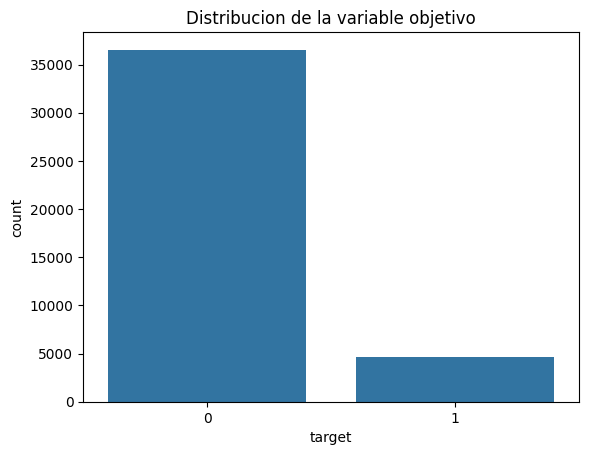

In [19]:
sns.countplot(x = df["target"])
plt.title("Distribucion de la variable objetivo")
plt.show()

# Bloque 4 - Separar features (X) y target (y)

In [20]:
X = df.drop(columns = ["target"])
y = df["target"]

In [21]:
X.shape, y.shape

((41188, 20), (41188,))

# Bloque 5 - Detectar columnas numericas y categoricas

In [24]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

In [25]:
print("Cat:", cat_cols)
print("Num:", num_cols)

Cat: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Num: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [26]:
# Vamos a quitar duration del modelo
if "duration" in num_cols:
    num_cols.remove("duration")
    X = X.drop(columns = ["duration"])

X.shape, len(cat_cols), len(num_cols)

((41188, 19), 10, 9)

# Bloque 6 - Preprocesador

In [27]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# Bloque 7 - Particion Train / Test

In [28]:
# Se utiliza un 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((32950, 19), (8238, 19))

# Bloque 8 - Definir modelo de regresion logistica

In [ ]:
# Bloque 8 – Comparación de muchos modelos 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier,
    BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate

import pandas as pd
import numpy as np

N_SPLITS = 5

# Se definen todos los modelos que se van a estar comparando
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_depth=None,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15
    ),
    "NaiveBayes": GaussianNB(),
    "SVM_RBF": SVC(
        kernel="rbf",
        probability=True,  
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=300,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="logloss",
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Bagging_DT": BaggingClassifier(
        estimator=DecisionTreeClassifier(), 
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}


cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

rows = []

for name, mdl in models.items():
    print(f"\n>>> Entrenando y evaluando: {name} ...")
    
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", mdl)
    ])
    
    cv_res = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    row = {"model": name}
    for metric in scoring.keys():
        test_scores = cv_res[f"test_{metric}"]
        row[f"{metric}_mean"] = np.mean(test_scores)
        row[f"{metric}_std"] = np.std(test_scores)
    
    rows.append(row)

results_models = (
    pd.DataFrame(rows)
      .sort_values(by="roc_auc_mean", ascending=False)
      .reset_index(drop=True)
)

results_models



>>> Entrenando y evaluando: LogisticRegression ...

>>> Entrenando y evaluando: RandomForest ...

>>> Entrenando y evaluando: HistGradientBoosting ...

>>> Entrenando y evaluando: GradientBoosting ...

>>> Entrenando y evaluando: ExtraTrees ...

>>> Entrenando y evaluando: AdaBoost ...

>>> Entrenando y evaluando: DecisionTree ...

>>> Entrenando y evaluando: KNN ...

>>> Entrenando y evaluando: NaiveBayes ...

>>> Entrenando y evaluando: SVM_RBF ...

>>> Entrenando y evaluando: MLP ...

>>> Entrenando y evaluando: XGBoost ...

>>> Entrenando y evaluando: CatBoost ...

>>> Entrenando y evaluando: LightGBM ...

>>> Entrenando y evaluando: Bagging_DT ...


,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
0,HistGradientBoosting,0.804952,0.011565,0.900772,0.001285,0.369191,0.006755,0.650688,0.017018,0.257759,0.005163
1,CatBoost,0.802633,0.011065,0.898733,0.002182,0.370942,0.014283,0.617919,0.022650,0.265086,0.011302
2,LightGBM,0.799706,0.012072,0.899728,0.002546,0.377392,0.017541,0.627736,0.025408,0.269828,0.013469
3,GradientBoosting,0.799131,0.009641,0.900723,0.001699,0.360429,0.005414,0.658152,0.026761,0.248276,0.003017
4,XGBoost,0.795059,0.010722,0.898563,0.001957,0.382419,0.014649,0.608533,0.017654,0.278879,0.012369
5,LogisticRegression,0.792137,0.009109,0.827498,0.003464,0.451329,0.008684,0.351716,0.007427,0.629741,0.011972
6,AdaBoost,0.789297,0.008901,0.899461,0.002146,0.314511,0.013768,0.678701,0.034363,0.204741,0.009220
7,SVM_RBF,0.776044,0.007387,0.849471,0.004563,0.478388,0.010764,0.392560,0.010645,0.612716,0.018647
8,RandomForest,0.773761,0.006044,0.891643,0.001748,0.373562,0.010239,0.535857,0.014886,0.286853,0.009839
9,NaiveBayes,0.767321,0.007836,0.801447,0.005910,0.409705,0.009557,0.308140,0.008851,0.611422,0.012578


# Bloque 9 - Mostrar resultados

In [ ]:
# Bloque 9 – Resumen de los modelos probados
results_models_rounded = results_models.copy()
metric_cols = [c for c in results_models.columns if c != "model"]
results_models_rounded[metric_cols] = results_models_rounded[metric_cols].round(4)

results_models_rounded


,model,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std
0,HistGradientBoosting,0.8050,0.0116,0.9008,0.0013,0.3692,0.0068,0.6507,0.0170,0.2578,0.0052
1,CatBoost,0.8026,0.0111,0.8987,0.0022,0.3709,0.0143,0.6179,0.0227,0.2651,0.0113
2,LightGBM,0.7997,0.0121,0.8997,0.0025,0.3774,0.0175,0.6277,0.0254,0.2698,0.0135
3,GradientBoosting,0.7991,0.0096,0.9007,0.0017,0.3604,0.0054,0.6582,0.0268,0.2483,0.0030
4,XGBoost,0.7951,0.0107,0.8986,0.0020,0.3824,0.0146,0.6085,0.0177,0.2789,0.0124
5,LogisticRegression,0.7921,0.0091,0.8275,0.0035,0.4513,0.0087,0.3517,0.0074,0.6297,0.0120
6,AdaBoost,0.7893,0.0089,0.8995,0.0021,0.3145,0.0138,0.6787,0.0344,0.2047,0.0092
7,SVM_RBF,0.7760,0.0074,0.8495,0.0046,0.4784,0.0108,0.3926,0.0106,0.6127,0.0186
8,RandomForest,0.7738,0.0060,0.8916,0.0017,0.3736,0.0102,0.5359,0.0149,0.2869,0.0098
9,NaiveBayes,0.7673,0.0078,0.8014,0.0059,0.4097,0.0096,0.3081,0.0089,0.6114,0.0126


In [53]:
# Tomar mejor modelo
best_row = results_models.iloc[0]
best_model_name = best_row["model"]

print("Mejor modelo segun roc auc")
print(best_row)
print(best_model_name)


Mejor modelo segun roc auc
model             HistGradientBoosting
roc_auc_mean                  0.804952
roc_auc_std                   0.011565
accuracy_mean                 0.900772
accuracy_std                  0.001285
f1_mean                       0.369191
f1_std                        0.006755
precision_mean                0.650688
precision_std                 0.017018
recall_mean                   0.257759
recall_std                    0.005163
Name: 0, dtype: object
HistGradientBoosting


# Bloque 10 - Definir pipeline final

In [42]:
# Bloque 10 – Definir pipeline final con HistGradientBoosting

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

hist_gb = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=None,
    max_leaf_nodes=31,
    l2_regularization=0.0,
    random_state=RANDOM_STATE
)

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", hist_gb)
])

final_model


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Bloque 11 - Entrenar modelo Final metricas Train / Test

In [ ]:

best_row_thr = threshold_table.loc[threshold_table["f1_1"].idxmax()]
THRESHOLD_OPT = float(best_row_thr["threshold"])

print("Mejor fila (según F1 de la clase 1):")
print(best_row_thr)
print("\nUmbral óptimo seleccionado:", THRESHOLD_OPT)


Mejor fila (según F1 de la clase 1):
threshold         0.250000
precision_1       0.462100
recall_1          0.545259
f1_1              0.500247
tp              506.000000
fp              589.000000
fn              422.000000
tn             6721.000000
Name: 3, dtype: float64

Umbral óptimo seleccionado: 0.25000000000000006


# Bloque 12 - Metricuas y matriz de confusion 

In [54]:
# Bloque 12 – Evaluar desempeño en TEST con el umbral óptimo

from sklearn.metrics import classification_report, confusion_matrix

y_test_pred_opt = (y_test_proba >= THRESHOLD_OPT).astype(int)

print(f"Resultados en TEST con umbral óptimo = {THRESHOLD_OPT:.2f} \n")
print(classification_report(y_test, y_test_pred_opt, digits=4))

print("Matriz de confusión TEST (umbral óptimo):")
print(confusion_matrix(y_test, y_test_pred_opt))


Resultados en TEST con umbral óptimo = 0.25 

              precision    recall  f1-score   support

           0     0.9409    0.9194    0.9300      7310
           1     0.4621    0.5453    0.5002       928

    accuracy                         0.8773      8238
   macro avg     0.7015    0.7323    0.7151      8238
weighted avg     0.8870    0.8773    0.8816      8238

Matriz de confusión TEST (umbral óptimo):
[[6721  589]
 [ 422  506]]


# Bloque 13 - Curvas

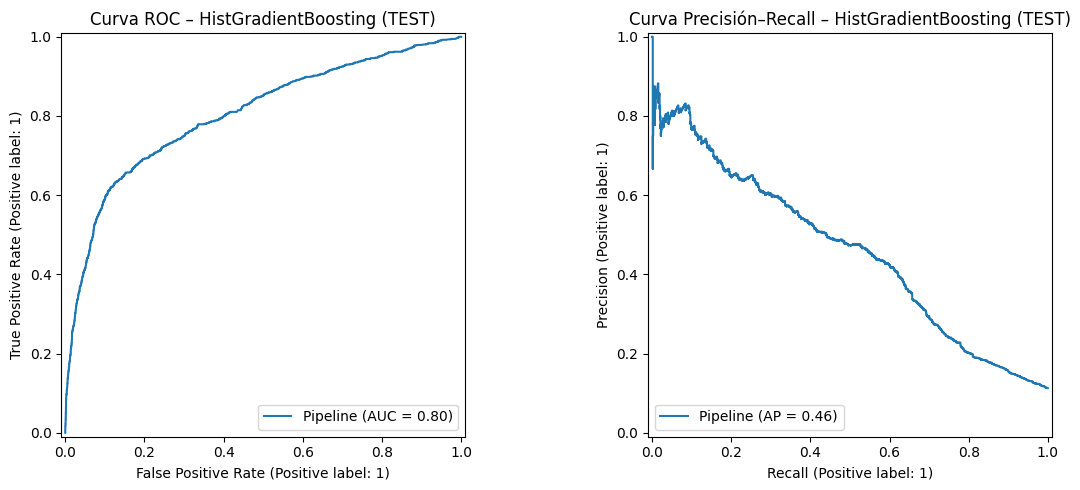

In [ ]:
# Bloque 13 – Curvas ROC y Precision-Recall 

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[0])
axes[0].set_title("Curva ROC – HistGradientBoosting (TEST)")

PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1])
axes[1].set_title("Curva Precisión–Recall – HistGradientBoosting (TEST)")

plt.tight_layout()
plt.show()


# Bloque 14 - Importancia Variables

In [ ]:
# Bloque 14 – Importancia de variables 

from sklearn.inspection import permutation_importance
import numpy as np

result = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importances_mean = result.importances_mean
importances_std  = result.importances_std

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

idx = np.argsort(importances_mean)[::-1][:20]

print("Top 20 variables más importantes:\n")
for i in idx:
    print(f"{feature_names[i]:40s}  {importances_mean[i]:.5f}  (+/- {importances_std[i]:.5f})")


Top 20 variables más importantes:

cat__job_technician                       0.01983  (+/- 0.00091)
cat__job_student                          0.00439  (+/- 0.00102)
cat__job_retired                          0.00296  (+/- 0.00085)
num__euribor3m                            0.00252  (+/- 0.00009)
cat__job_entrepreneur                     0.00223  (+/- 0.00080)
cat__job_blue-collar                      0.00121  (+/- 0.00076)
cat__job_admin.                           0.00104  (+/- 0.00067)
cat__job_housemaid                        0.00090  (+/- 0.00012)
num__nr.employed                          0.00073  (+/- 0.00030)
cat__job_management                       0.00049  (+/- 0.00020)
cat__job_self-employed                    0.00044  (+/- 0.00042)
num__previous                             0.00036  (+/- 0.00023)
num__age                                  0.00034  (+/- 0.00050)
num__campaign                             0.00024  (+/- 0.00025)
num__pdays                                0.00017  (+/-

# Bloque 15 - Guardar Modelo

In [ ]:
import pickle

artefacto = {
    "model": final_model,
    "threshold": THRESHOLD_OPT
}

model_path = "histgb_bank_pipeline_with_threshold.pkl"

with open(model_path, "wb") as f:
    pickle.dump(artefacto, f)

print(f"Modelo + umbral guardados en: {model_path}")


Modelo + umbral guardados en: histgb_bank_pipeline_with_threshold.pkl


# Funcion a usar en produccion

In [ ]:


def prob_to_level(p: float) -> str:
    """
    Mapea probabilidad a nivel cualitativo.
    Ajusta umbrales si quieres otros cortes.
    """
    if p < 0.25:
        return "Baja"
    elif p < 0.5:
        return "Media"
    else:
        return "Alta"

def predict_cliente(artefacto, X_row: pd.DataFrame):
    """
    artefacto: dict con 'model' y 'threshold'
    X_row: DataFrame con UNA fila (cliente a evaluar)
    """
    model = artefacto["model"]
    thr   = artefacto["threshold"]
    
    proba = model.predict_proba(X_row)[0, 1]
    clase = int(proba >= thr)
    nivel = prob_to_level(proba)
    
    return proba, clase, nivel

with open(model_path, "rb") as f:
    artefacto_cargado = pickle.load(f)

ejemplo = X.iloc[[0]] 

proba, clase, nivel = predict_cliente(artefacto_cargado, ejemplo)

print(f"Probabilidad de aceptación: {proba:.4f}")
print(f"Clase (0=No, 1=Sí): {clase}")
print(f"Nivel cualitativo: {nivel}")


Probabilidad de aceptación: 0.0291
Clase (0=No, 1=Sí): 0
Nivel cualitativo: Baja


# Función para meter valores y obtener la predicción

In [3]:
with open("histgb_bank_pipeline_with_threshold.pkl", "rb") as f:
    artefacto_cargado = pickle.load(f)


In [6]:
def predict_from_values(
    artefacto,
    *,
    age,
    job,
    marital,
    education,
    default,
    housing,
    loan,
    contact,
    month,
    day_of_week,
    campaign,
    pdays,
    previous,
    poutcome,
    emp_var_rate,
    cons_price_idx,
    cons_conf_idx,
    euribor3m,
    nr_employed
):
    """
    Recibe el diccionario artefacto = {"model": ..., "threshold": ...}
    y los valores de un cliente, construye la fila y devuelve la predicción.
    
    Parámetros (todos obligatorios, van como keyword arguments):
      - age: Edad del cliente (int, ej. 42)
      - job: Tipo de trabajo (str, ej. "admin.", "technician", "blue-collar"...)
      - marital: Estado civil (str, ej. "married", "single", "divorced")
      - education: Nivel educativo (str, ej. "university.degree", "high.school", "basic.9y"...)
      - default: ¿Tiene crédito en default? ("yes", "no", "unknown")
      - housing: ¿Tiene préstamo de vivienda? ("yes", "no", "unknown")
      - loan: ¿Tiene préstamo personal? ("yes", "no", "unknown")
      - contact: Medio de contacto ("cellular" o "telephone")
      - month: Mes de la última campaña ("jan","feb",...,"dec")
      - day_of_week: Día de la semana ("mon","tue","wed","thu","fri")
      - campaign: Número de contactos realizados en esta campaña (int)
      - pdays: Días desde el último contacto en una campaña anterior (999 = nunca contactado)
      - previous: Nº de contactos previos antes de esta campaña (int)
      - poutcome: Resultado de la campaña anterior ("success","failure","nonexistent")
      - emp_var_rate: Tasa de variación del empleo (float, indicador macroeconómico)
      - cons_price_idx: Índice de precios al consumidor (float)
      - cons_conf_idx: Índice de confianza del consumidor (float)
      - euribor3m: Tipo Euribor a 3 meses (float)
      - nr_employed: Nº de empleados (indicador agregado bancario, float)
    """
    model = artefacto["model"]
    thr   = artefacto["threshold"]
    
    # Armar diccionario con los nombres EXACTOS de las columnas de X
    data_dict = {
        "age": age,
        "job": job,
        "marital": marital,
        "education": education,
        "default": default,
        "housing": housing,
        "loan": loan,
        "contact": contact,
        "month": month,
        "day_of_week": day_of_week,
        "campaign": campaign,
        "pdays": pdays,
        "previous": previous,
        "poutcome": poutcome,
        "emp.var.rate": emp_var_rate,
        "cons.price.idx": cons_price_idx,
        "cons.conf.idx": cons_conf_idx,
        "euribor3m": euribor3m,
        "nr.employed": nr_employed,
    }
    
    # Convertir a DataFrame de UNA fila
    fila = pd.DataFrame([data_dict])
    
    # Probabilidad de clase 1
    proba = model.predict_proba(fila)[0, 1]
    # Clase binaria usando tu umbral óptimo
    clase = int(proba >= thr)
    
    # Nivel cualitativo (puedes ajustar cortes si quieres)
    if proba < 0.25:
        nivel = "Baja"
    elif proba < 0.5:
        nivel = "Media"
    else:
        nivel = "Alta"
    
    # Devolvemos todo junto
    return {
        "probabilidad": float(proba),
        "clase": clase,        # 0 = No, 1 = Sí
        "nivel": nivel,
        "threshold_usado": thr
    }


In [7]:
ejemplo_res = predict_from_values(
    artefacto_cargado,
    age=42,
    job="admin.",
    marital="married",
    education="university.degree",
    default="no",
    housing="yes",
    loan="no",
    contact="cellular",
    month="may",
    day_of_week="mon",
    campaign=1,
    pdays=999,
    previous=0,
    poutcome="nonexistent",
    emp_var_rate=1.4,
    cons_price_idx=93.918,
    cons_conf_idx=-42.5,
    euribor3m=4.963,
    nr_employed=5228.1
)

ejemplo_res


{'probabilidad': 0.0519671242495296,
 'clase': 0,
 'nivel': 'Baja',
 'threshold_usado': 0.25000000000000006}